# MNIS

* MNIST 데이터셋은 미국국립표준기술원(NIST)에서 고등학생과 인구조사국 직원 등이 쓴 손글씨를 이용해 만든 이미지 데이터셋
* 70000개의 숫자 이미지에 각각 0부터 9까지 레이블을 붙인 데이터셋
* 70000개의 숫자는 학습용 60000개와 평가용 10000개로 분할되어 있음
<br><br>
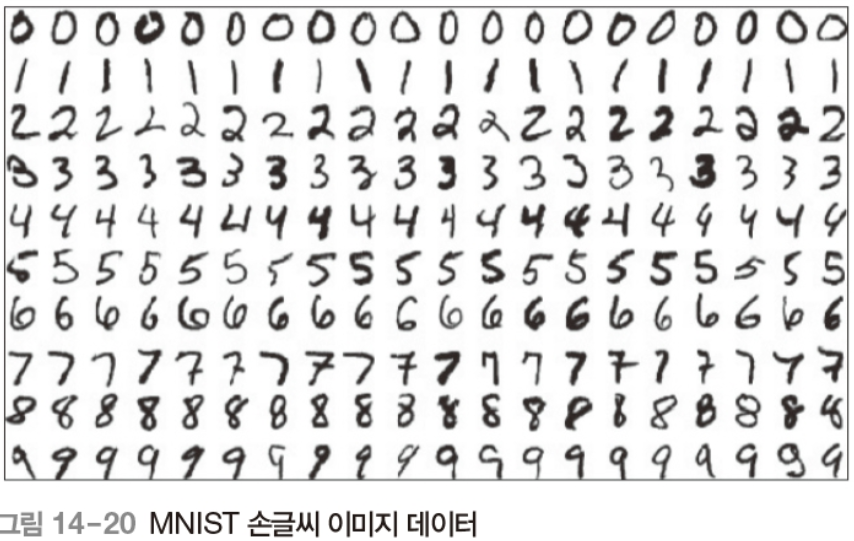

1. 데이터 로드 및 전처리: MNIST 데이터를 로드하고, 정규화 및 원-핫 인코딩을 수행
2. 모델 설계: CNN 모델을 설계하여 이미지 분류 작업
3. 모델 컴파일: 손실 함수와 최적화 방법을 설정
4. 모델 훈련: 데이터를 훈련하여 모델을 학습
5. 모델 평가: 성능 평가
6. 결과 시각화: 훈련 성과 분석

In [2]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics
import yfinance as yf
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from prophet.plot import add_changepoints_to_plot, plot_plotly, plot_components_plotly
from prophet import Prophet
from openpyxl import load_workbook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

## 1. 데이터 로드 및 전처리

### 1. 데이터 로드

In [1]:
from keras.datasets import mnist

In [ ]:
(X_train_0, Y_train_0), (X_test_0, Y_test_0) = mnist.load_data()    # # Keras에서 제공하는 MNIST 손글씨 데이터셋을 불러오기

## mnist의 이미지는 28x28, 흑백이미지
## train용의 경우, cnn모델에 사용하기 위하여 (60000, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
print("학습 데이터 수 : %d"%(X_train_0.shape[0]))
print("평가 데이터 수 : %d"%(X_test_0.shape[0]))

학습 데이터 수 : 60000
평가 데이터 수 : 10000


### 2. 입력 학습 데이터 : X_train[0] 이미지 출력

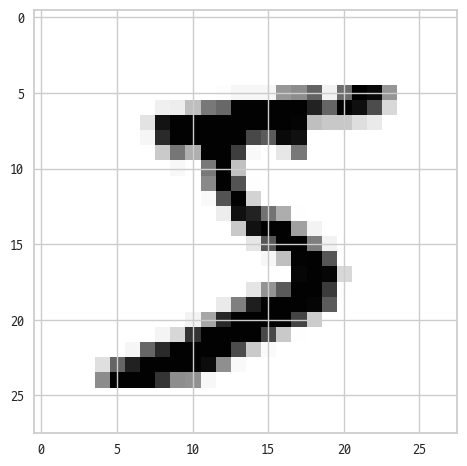

In [6]:
plt.imshow(X_train_0[0], cmap='Grays')

### 3. 출력 학습 데이터(레이블) : Y_train

In [7]:
print("class : %d " % (Y_train_0[0]))

class : 5 


In [ ]:
## X_train_0[0] 벡터 출력
for x in X_train_0[0]:
    for i in x:
        print(f'{i:4d}', end='')
    print()

## MNIST는 검정바탕에 흰색 글씨로 되어있다.

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0

### 4. 데이터 정규화 : {0 ~255} -> {0.0 ~ 1.0}

In [9]:
X_train = X_train_0.reshape(X_train_0.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test_0.reshape(X_test_0.shape[0], 28, 28, 1).astype('float32') / 255

In [10]:
## X_train[0] 벡터 출력
for x in X_train[0]:
    for i in x:
        print(f'{i[0]:.2f} ', end='')
    print()

0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.01 0.07 0.07 0.07 0.49 0.53 0.69 0.10 0.65 1.00 0.97 0.50 0.00 0.00 0.00 0.00 
0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.12 0.14 0.37 0.60 0.67 0.99 0.99 0.99 0.99 0.99 0.88 0.67 0.99 0.95 0.76 0.25 0.00 0.00 0.00 0.00 
0.00 0.00 0.0

### 5. 출력값을 0~9 카테고리 벡터로 변형

In [11]:
from tensorflow.python.keras.utils import np_utils

Y_train = np_utils.to_categorical(Y_train_0, 10)
Y_test = np_utils.to_categorical(Y_test_0, 10)

print(Y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 2. CNN 모델

In [12]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint,EarlyStopping

import os

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2))    ## pool_size=2의 의미는 (2, 2)
# model.add(Dropout(0.25))   ## 무작위로 25% 데이터를 버려서 과적합 방지
model.add(Flatten())
model.add(Dense(128,  activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [14]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
# 모델 저장 경로 설정 및 폴더 생성
MODEL_DIR = '../../data/model/'
if not os.path.exists(MODEL_DIR): 
    os.mkdir(MODEL_DIR)

# ModelCheckpoint: 성능이 좋아질 때마다 모델을 파일로 저장
modelpath= "../../data/model/{epoch:02d}-{val_loss:.4f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
# EarlyStopping: 테스트 오차가 줄어들지 않으면(5번) 학습을 조기 종료
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 학습 실행: 200개씩 묶어서(batch) 전체를 30번(epoch) 반복 학습
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), \
                    epochs=30, batch_size=200, verbose=1, \
                    callbacks=[early_stopping_callback,checkpointer])

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9922 - loss: 0.0246
Epoch 1: val_loss improved from None to 0.02613, saving model to ../../data/model/01-0.0261.keras

Epoch 1: finished saving model to ../../data/model/01-0.0261.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 59s 196ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9927 - val_loss: 0.0261
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9934 - loss: 0.0201
Epoch 2: val_loss did not improve from 0.02613
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 224ms/step - accuracy: 0.9930 - loss: 0.0213 - val_accuracy: 0.9917 - val_loss: 0.0280
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.9937 - loss: 0.0188
Epoch 3: val_loss improved from 0.02613 to 0.02414, saving model to ../../data/model/03-0.0241.keras

Epoch 3: finished saving model to ../../data/model/03-0.0241.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 66s 220ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9930 - val_loss: 0

In [17]:
test_num = X_train[0].reshape(-1, 28, 28, 1)

prediction = model.predict(test_num)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


In [ ]:
print('입력한 이미지는 %f 확률로 %d 입니다!'%(prediction[0, prediction.argmax()], prediction.argmax()))

입력한 이미지는 0.999997 확률로 5 입니다!


In [21]:
test_num = X_train[3].reshape(-1, 28, 28, 1)

prediction = model.predict(test_num)

print('입력한 이미지는 %f 확률로 %d 입니다!'%(prediction[0, prediction.argmax()], prediction.argmax()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
입력한 이미지는 1.000000 확률로 1 입니다!


In [22]:
print("class : %d " % (Y_train_0[3]))

class : 1 
